# Renger 2026 Fig. 2 MOVE Branch Labeling Walkthrough

**Audience**
- Julia users who already know the `QuantumCircuit.jl` system/model split and want a cleaner avoided-crossing workflow for the Fig. 2 move branch.

**Prerequisites**
- Basic Julia syntax.
- Familiarity with `CompositeSystem`, `CircuitHamiltonianSpec`, and the Renger 2026 snapshot files.
- A working local checkout of this repository.

**What you will learn**
- How to build a thin Fig. 2 branch system without depending on the giant legacy helper.
- How to use `simulate_eigensystem_sweep`, `bare_product_basis`, and `label_sweep` to track bare labels through a dressed exact-circuit sweep.
- How to inspect the crossing neighborhood with `energy_curve` and `dressed_state_components`.
- How a stricter overlap threshold exposes low-confidence labels as `NaN` gaps in the tracked curves.

**Runtime profile**
- This notebook stays on a 1D branch cut for the Fig. 2 move branch.
- Default settings use `charge_cutoff = 10`, `17` flux points, and `6` dressed levels, which keeps the run interactive while staying physically aligned with the current retune overlay.


## Outline

1. Activate the local package environment and load the thin Fig. 2 labeling helper.
2. Load the frozen snapshot and assemble the exact `QB1-TC1-CR` move-branch system.
3. Run a 1D exact-circuit eigensystem sweep and build a fixed bare-product basis.
4. Plot bare-labeled dressed curves across the crossing neighborhood.
5. Inspect the dressed-state composition at the minimum labeled gap.
6. Raise the overlap threshold and see where labels become low-confidence.
7. Optionally compare the labeled crossing point against the legacy helper summary.


In [2]:
using Pkg

function find_repo_root(start::AbstractString)
    candidates = [
        normpath(start),
        normpath(joinpath(start, "..")),
        normpath(joinpath(start, "..", "..")),
    ]

    for candidate in unique(candidates)
        project_toml = joinpath(candidate, "Project.toml")
        if isfile(project_toml)
            content = read(project_toml, String)
            occursin("QuantumCircuit", content) && return candidate
        end
    end

    error("Could not find the QuantumCircuit.jl project root. Start Jupyter from the repository or open the notebook from inside it.")
end

repo_root = find_repo_root(pwd())
Pkg.activate(repo_root)
Pkg.instantiate()

using CairoMakie
using QuantumCircuit

include(joinpath(repo_root, "output", "jupyter-notebook", "makie_helpers.jl"))
include(joinpath(repo_root, "output", "jupyter-notebook", "renger2026_fig2_labeling_helpers.jl"))
activate_notebook_theme!()

nothing


  Activating project at `~/Research/20_Projects/QuantumCircuit.jl`


## Step 1 - Load the snapshot and assemble the move branch

The thin helper only does four things here: resolve the baseline and overlay paths, load the merged snapshot, expose the move-branch defaults, and assemble the exact `QB-TC-CR` circuit system for one fixed `TC` flux cut.

The exact branch Hamiltonian we study is

$$
H_{\mathrm{move}}(\Phi_Q; \Phi_{TC}^{\star}) = H_{QB}(\Phi_Q) + H_{TC}(\Phi_{TC}^{\star}) + H_{CR}
+ G_{QB,TC}\,\hat n_{QB}\hat n_{TC} + G_{TC,CR}\,\hat n_{TC}\hat x_{CR}.
$$

In this notebook, `TC` flux is held fixed at a single cut value,

$$
\Phi_{TC}^{\star} = 0.34,
$$

while the qubit flux is the control parameter we sweep,

$$
\Phi_Q \in [0.0, 0.5].
$$

So the system itself is always the same three-body branch, `QB1-TC1-CR`; only the `QB` subsystem flux changes from point to point along the cut.


In [3]:
paths = fig2_snapshot_paths(repo_root)
snapshot = load_fig2_labeling_snapshot(repo_root)
defaults = fig2_branch_defaults(:move; q_points = 17, charge_cutoff = 10)
defaults = merge(defaults, (; q_fluxes = collect(range(0.0, 0.5; length = 501))))


branch_system = fig2_branch_system(
    snapshot;
    branch = defaults.branch,
    q_flux = first(defaults.q_fluxes),
    tc_flux = defaults.tc_flux,
    qubit_ncut = defaults.qubit_ncut,
    coupler_ncut = defaults.coupler_ncut,
    resonator_dim = defaults.resonator_dim,
)

defaults_summary = (
    branch = defaults.branch,
    branch_label = defaults.branch_label,
    q_flux_start = first(defaults.q_fluxes),
    q_flux_stop = last(defaults.q_fluxes),
    q_points = length(defaults.q_fluxes),
    tc_flux = defaults.tc_flux,
    target_labels = defaults.target_labels,
    charge_cutoff = defaults.charge_cutoff,
)

(
    snapshot_paths = paths,
    branch_defaults = fig2_compact_namedtuple(defaults_summary),
    branch_summary = fig2_compact_namedtuple(fig2_branch_summary(snapshot; branch = defaults.branch, defaults = defaults)),
)


(snapshot_paths = (baseline_path = "/Users/yalgaeahn/Research/20_Projects/QuantumCircuit.jl/output/renger2026/paper_local_priors.toml", overlay_path = "/Users/yalgaeahn/Research/20_Projects/QuantumCircuit.jl/output/renger2026/fig2_ef_retune_working.toml"), branch_defaults = (branch = :move, branch_label = "QB1-TC1-CR", q_flux_start = 0.0, q_flux_stop = 0.5, q_points = 501.0, tc_flux = 0.34, target_labels = ((1, 0, 0), (0, 0, 1)), charge_cutoff = 10.0), branch_summary = (branch = :move, branch_label = "QB1-TC1-CR", qb_device = "QB1", tc_device = "TC1", target_labels = ((1, 0, 0), (0, 0, 1)), q_flux_window = (0.0, 0.5), tc_flux = 0.34, qb_f01_ghz = 4.6679, tc_f01_ghz = 5.3516, cr_f01_ghz = 4.3, beta_qc = 0.023, beta_cr = 0.026, charge_cutoff = 10.0))

## Step 2 - Sweep the exact circuit model and label the dressed states

This is the new package-level path. The notebook does not ask the helper to analyze the crossing. Instead it runs `simulate_eigensystem_sweep`, builds a fixed isolated-subsystem bare basis, and uses `label_sweep` to map bare labels onto dressed branches.

At each sweep point we diagonalize the full coupled branch Hamiltonian,

$$
H_{\mathrm{move}}(\Phi_Q)\,|\psi_k(\Phi_Q)\rangle = E_k(\Phi_Q)\,|\psi_k(\Phi_Q)\rangle.
$$

But the labels are not assigned from the dressed eigenstates alone. We first define a fixed bare-product basis at one reference operating point,

$$
\mathcal{B}_{\mathrm{bare}}^{(\mathrm{ref})}
= \{ |q,t,c\rangle_{\mathrm{ref}} \}
= |q\rangle_{QB}(\Phi_Q^{\mathrm{ref}}) \otimes |t\rangle_{TC}(\Phi_{TC}^{\star}) \otimes |c\rangle_{CR},
$$

where this notebook takes

$$
\Phi_Q^{\mathrm{ref}} = \min(\texttt{defaults.q\_fluxes}).
$$

Then `label_sweep` matches each dressed branch to the bare label with the largest overlap,

$$
\ell_k(\Phi_Q) = \arg\max_{b \in \mathcal{B}_{\mathrm{bare}}^{(\mathrm{ref})}} |\langle b | \psi_k(\Phi_Q) \rangle|^2.
$$

For the move crossing, the two target labels are

$$
|100\rangle \quad \text{and} \quad |001\rangle,
$$

so the notebook is explicitly asking: as `QB` flux changes, which dressed branches continue to look most like those two bare branch states?


In [4]:
hamiltonian_spec = CircuitHamiltonianSpec(charge_cutoff = defaults.charge_cutoff)
branch_cut = SweepSpec(:QB, :flux, defaults.q_fluxes; levels = defaults.levels)

sweep = simulate_eigensystem_sweep(branch_system, branch_cut; hamiltonian_spec = hamiltonian_spec)
basis = bare_product_basis(
    branch_system;
    hamiltonian_spec = hamiltonian_spec,
    subsystem_levels = defaults.subsystem_levels,
)
labeled = label_sweep(sweep, basis)
strict_labeled = label_sweep(sweep, basis; overlap_threshold = 0.99)

(
    sweep_points = length(sweep.values),
    lowest_levels = length(sweep.spectra[1].energies),
    basis_labels = basis.labels,
    first_target_index = dressed_index(labeled, defaults.target_labels[1], 1),
    second_target_index = dressed_index(labeled, defaults.target_labels[2], 1),
)


(sweep_points = 501, lowest_levels = 6, basis_labels = Tuple[(0, 0, 0), (1, 0, 0), (2, 0, 0), (0, 1, 0), (1, 1, 0), (2, 1, 0), (0, 0, 1), (1, 0, 1), (2, 0, 1), (0, 1, 1), (1, 1, 1), (2, 1, 1)], first_target_index = 4, second_target_index = 3)

## Step 3 - Plot the bare-labeled dressed curves

The x-axis below is not raw flux. It is the isolated qubit `f01` along the same branch cut, which makes the crossing easier to compare against the legacy Fig. 2(c) view.

Concretely, the horizontal axis is

$$
\omega_{QB,01}(\Phi_Q) = E^{QB}_1(\Phi_Q) - E^{QB}_0(\Phi_Q),
$$

The dashed gray guides are still the bare-labeled curves,

$$
E_{|100\rangle}(\Phi_Q) \quad \text{and} \quad E_{|001\rangle}(\Phi_Q).
$$

But the solid colored curves are now the actual adiabatic eigen-branches of one selected dressed-state pair,

$$
E_{k_{\mathrm{lower}}}(\Phi_Q) \quad \text{and} \quad E_{k_{\mathrm{upper}}}(\Phi_Q),
$$

where `(k_lower, k_upper)` is chosen from the two dressed states that carry the target bare labels at the best labeled crossing point.

So the figure is best read as: move along the `QB` flux cut, convert that cut to the local qubit frequency axis, use bare labeling only to identify the relevant branch pair, and then plot the adiabatic upper/lower eigenenergy curves themselves.

If the sweep window is wide, one of the two labels may disappear over part of the cut. The notebook therefore searches for the minimum gap only inside the valid labeled subset,

$$
\mathcal{I}_{\mathrm{valid}} = \left\{ i : E_{|100\rangle}(\Phi_Q^{(i)}) \text{ and } E_{|001\rangle}(\Phi_Q^{(i)}) \text{ are both finite} \right\},
$$

instead of taking `argmin` over the full sweep window.


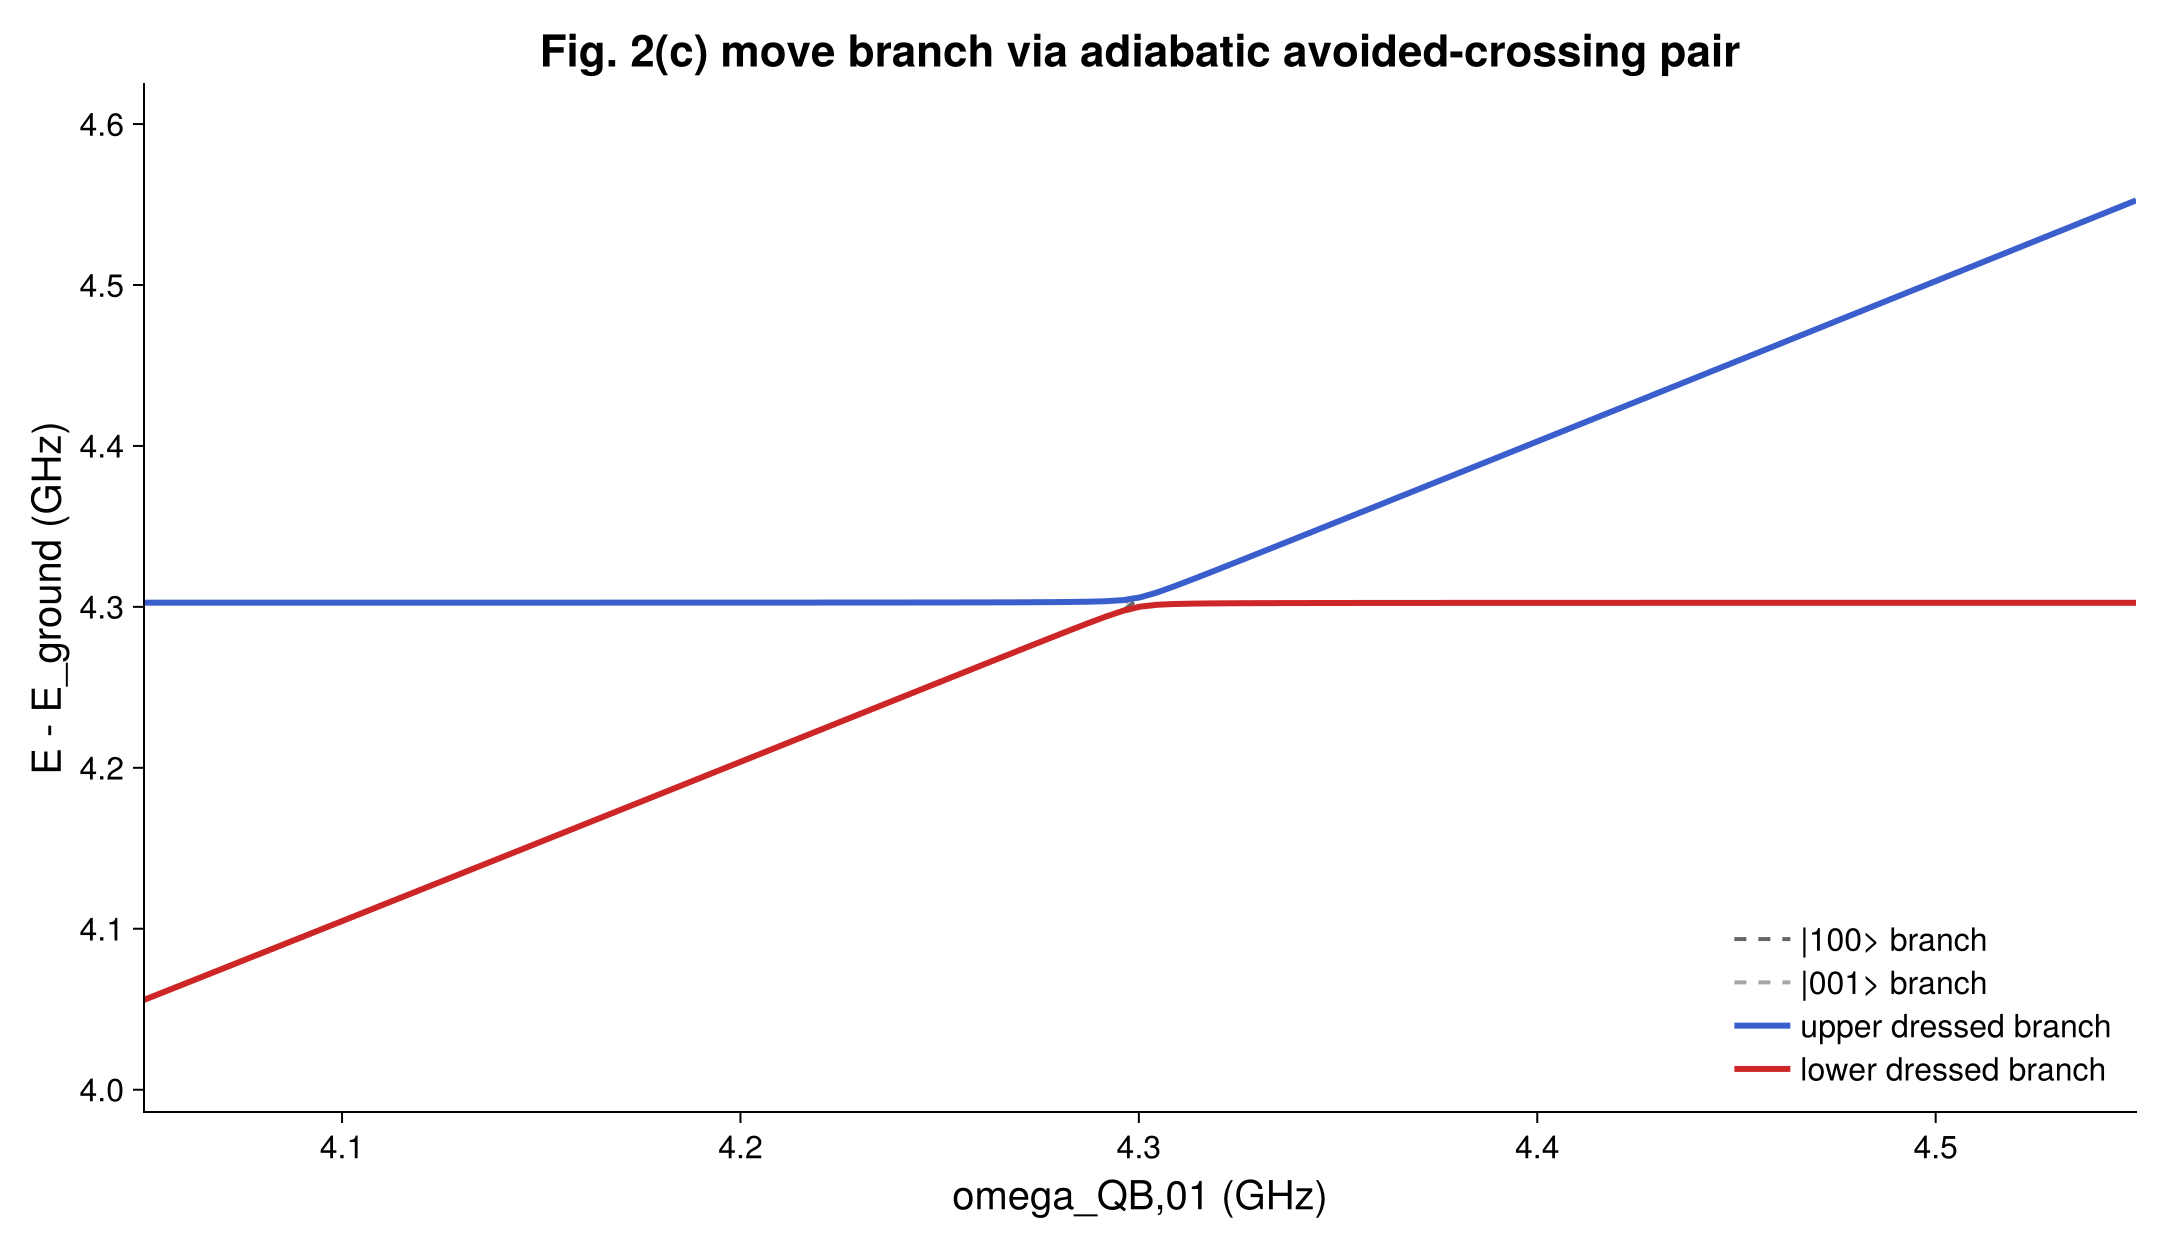

(valid_labeled_window = (first_q_flux = 0.0, last_q_flux = 0.422, count = 422.0), crossing_summary = (index = 176.0, valid_indices = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10  …  414, 415, 416, 417, 418, 419, 420, 421, 422, 423], valid_count = 422.0, dressed_index_a = 4.0, dressed_index_b = 3.0, pair_abs = (3, 4), q_flux = 0.175, q_ghz = 4.3003, bare_energy_a = 4.3059, bare_energy_b = 4.3001, labeled_gap_ghz = 0.0057))

In [9]:
q_frequency_axis = fig2_qubit_frequency_axis(
    snapshot,
    defaults.q_fluxes;
    branch = defaults.branch,
    charge_cutoff = defaults.charge_cutoff,
    qubit_ncut = defaults.qubit_ncut,
)

curve_100 = energy_curve(labeled, defaults.target_labels[1]; subtract_ground = true)
curve_001 = energy_curve(labeled, defaults.target_labels[2]; subtract_ground = true)
crossing_summary = fig2_best_labeled_crossing(
    labeled,
    defaults.q_fluxes,
    q_frequency_axis;
    bare_labels = defaults.target_labels,
    subtract_ground = true,
)
crossing_index = crossing_summary.index
valid_labeled_window = (
    first_q_flux = defaults.q_fluxes[first(crossing_summary.valid_indices)],
    last_q_flux = defaults.q_fluxes[last(crossing_summary.valid_indices)],
    count = crossing_summary.valid_count,
)

crossing_fig = fig2_adiabatic_crossing_figure(
    q_frequency_axis,
    labeled;
    pair_abs = crossing_summary.pair_abs,
    branch = defaults.branch,
    title = "Fig. 2(c) move branch via adiabatic avoided-crossing pair",
    include_bare_guides = true,
    x_center = crossing_summary.q_ghz,
    x_half_width = 0.25,
)
display(crossing_fig)

(
    valid_labeled_window = fig2_compact_namedtuple(valid_labeled_window),
    crossing_summary = fig2_compact_namedtuple(crossing_summary),
)


## Step 4 - Inspect the dressed-state composition at the crossing point

A bare-labeled curve is only useful if the dressed state really carries the expected branch character. The next cell asks for the top bare components of both labeled branches right where the labeled gap is smallest inside that valid labeled region.


In [10]:
probe_components_100 = dressed_state_components(labeled, defaults.target_labels[1], crossing_index; top = 5)
probe_components_001 = dressed_state_components(labeled, defaults.target_labels[2], crossing_index; top = 5)

(
    probe_point = fig2_compact_namedtuple((q_flux = defaults.q_fluxes[crossing_index], q_ghz = q_frequency_axis[crossing_index])),
    components_for_100 = probe_components_100,
    components_for_001 = probe_components_001,
)


(probe_point = (q_flux = 0.175, q_ghz = 4.3003), components_for_100 = Pair{Tuple, Float64}[(1, 0, 0) => 0.5595754280738237, (0, 0, 1) => 0.41479577262979744, (0, 1, 0) => 0.010898404921365672, (2, 0, 0) => 0.0061058421021006025, (0, 0, 0) => 0.0036198439533145187], components_for_001 = Pair{Tuple, Float64}[(0, 0, 1) => 0.5732836009485568, (1, 0, 0) => 0.4140467238698553, (2, 0, 0) => 0.004518123058902371, (1, 0, 1) => 0.003387359742883478, (0, 0, 0) => 0.0026784347145451136])

## Step 5 - Raise the overlap threshold and expose low-confidence labels

This is the scqubits-style safety valve. We do not force a bare label onto every dressed state. Instead we raise the overlap threshold and let weak assignments drop out as `NaN` in the tracked energy curves.

The rule is

$$
\max_{b \in \mathcal{B}_{\mathrm{bare}}^{(\mathrm{ref})}} |\langle b | \psi_k(\Phi_Q) \rangle|^2 < \tau
\quad \Longrightarrow \quad
\text{label} = \texttt{missing},
$$

with this notebook taking

$$
\tau = 0.99
$$

in the strict view below. If a branch no longer looks enough like its reference bare state, `energy_curve` reports `NaN` at that sweep point instead of pretending the label is still trustworthy.


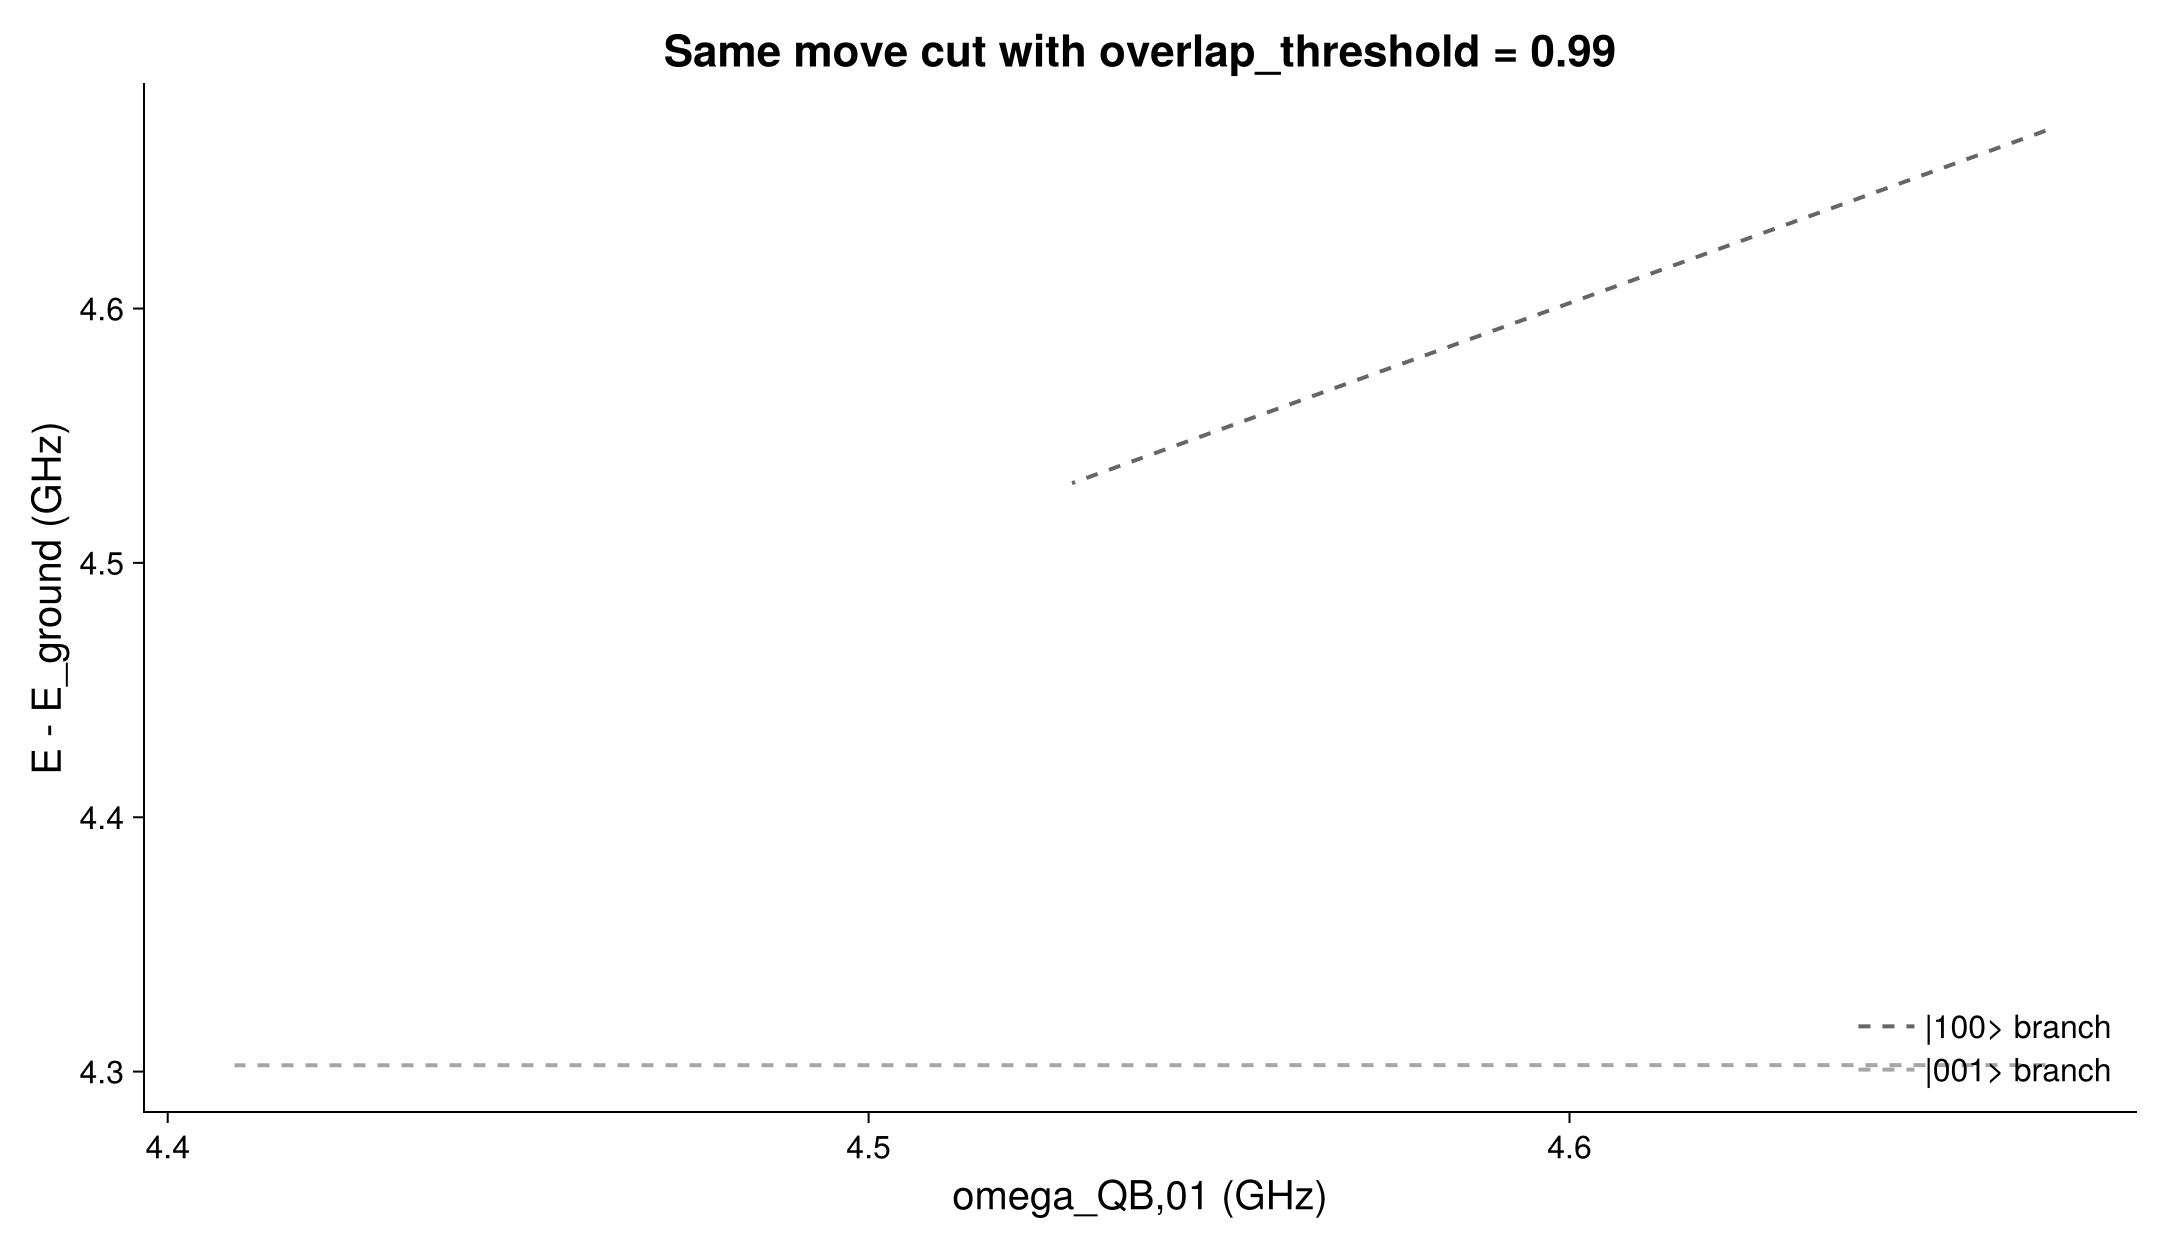

(overlap_threshold = 0.99, missing_points_for_100 = 392, missing_points_for_001 = 353, final_label_map = Union{Missing, Int64}[missing, missing, missing, missing, missing, missing, missing, missing, missing, missing, missing, missing])

In [12]:
strict_curve_100 = energy_curve(strict_labeled, defaults.target_labels[1]; subtract_ground = true)
strict_curve_001 = energy_curve(strict_labeled, defaults.target_labels[2]; subtract_ground = true)

strict_fig = fig2_labeled_crossing_figure(
    q_frequency_axis,
    strict_labeled;
    branch = defaults.branch,
    title = "Same move cut with overlap_threshold = 0.99",
)
display(strict_fig)

(
    overlap_threshold = 0.99,
    missing_points_for_100 = count(isnan, strict_curve_100.data),
    missing_points_for_001 = count(isnan, strict_curve_001.data),
    final_label_map = strict_labeled.label_maps[end].bare_to_dressed,
)


## Step 6 - Optional comparison against the legacy helper

The next cell is disabled by default. If you flip the flag, it recomputes the same 1D cut with the legacy Fig. 2 helper and compares the crossing point summary against the new labeled result.


In [15]:
RUN_REFERENCE_COMPARISON = true

if RUN_REFERENCE_COMPARISON
    include(joinpath(repo_root, "output", "jupyter-notebook", "renger2026_fig2_branch_helpers.jl"))
    reference_rows = adiabatic_fan_rows(
        branch_system,
        snapshot,
        defaults.q_fluxes,
        defaults.tc_flux;
        branch_pair_a = defaults.target_labels[1],
        branch_pair_b = defaults.target_labels[2],
        which = :move,
        branch = defaults.branch,
        charge_cutoff = defaults.charge_cutoff,
        fan_levels = defaults.levels,
        qb_ncut = defaults.qubit_ncut,
        tc_ncut = defaults.coupler_ncut,
        resonator_dim = defaults.resonator_dim,
    )
    reference_pair = choose_highlighted_pair(reference_rows)
    reference_gap = adiabatic_gap_summary(reference_rows, reference_pair)

    (
        labeled_reference = fig2_compact_namedtuple(crossing_summary),
        helper_reference = fig2_compact_namedtuple((
            q_flux = reference_gap.q_flux,
            q_ghz = reference_gap.q_ghz,
            gap_ghz = reference_gap.gap_ghz,
        )),
    )
else
    "Reference comparison skipped. Set RUN_REFERENCE_COMPARISON = true to compare against the legacy helper."
end


LoadError: UndefVarError: `eigenstates` not defined in `Main`
Suggestion: check for spelling errors or missing imports.
Hint: a global variable of this name also exists in QuantumToolbox.

  Julia 1.12 has introduced more strict world age semantics for global bindings.
  !!! This code may malfunction under Revise.
  !!! This code will error in future versions of Julia.
Hint: Add an appropriate `invokelatest` around the access to this binding.
To make this warning an error, and hence obtain a stack trace, use `julia --depwarn=error`.


## Takeaways

- The thin helper only assembles the Fig. 2 move branch and prepares the axis defaults.
- The actual crossing analysis now lives in the package-level labeling path.
- `energy_curve` gives the tracked bare-labeled branch, and `dressed_state_components` tells you whether that label is still physically honest near the crossing.
- A higher threshold is not a cosmetic option. It is an explicit confidence boundary for when a bare label should stop being trusted.
